# LSTM Notebook

This notebook provides an example of working with the LSTM model. It
shows the process of loading per-game data for premier league forwards for
the current season, splitting into train/test sets, creating datasets and
dataloaders from them, training a `FootballLSTM` instance, and evaluating
it.

In [1]:
import sys
import os
from understatapi import UnderstatClient
import torch
from torch.utils.data import DataLoader
import torch.nn as nn

# Also import local helpers
target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)
    
from preprocess import get_position_players_stats_df, CustomFootballDataset
from football_lstm import FootballLSTM

In [2]:
# Create understat connection
understat = UnderstatClient()

In [ ]:
# Choose what stats to forecast, and how many past games to use to predict
# the current one
stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
games_per_block = 5

In [ ]:
# Get forward stats for 2025 PL season
f_stats = get_position_players_stats_df(understat, ['F'], games_per_block, stats)
f_stats.head()

goals_per_90  xG_per_90  assists_per_90  xA_per_90  \
player_id date                                                             
8260      2020-05-23      1.304348   0.786954        0.260870   0.134672   
          2020-10-24      0.953642   0.722319        0.238411   0.219485   
          2021-02-06      0.910112   0.875012        0.101124   0.056400   
          2021-04-21      0.928899   0.981479        0.206422   0.121456   
          2021-11-27      1.527273   1.000932        0.436364   0.366922   

                      key_passes_per_90  xGChain_per_90  xGBuildup_per_90  
player_id date                                                             
8260      2020-05-23           1.043478        1.040308          0.384068  
          2020-10-24           1.072848        0.865080          0.070795  
          2021-02-06           0.505618        0.988297          0.206671  
          2021-04-21           1.238532        1.097435          0.340494  
          2021-11-27           1.200000        1.173353          0.064102

In [5]:
# Train/test split
train_len = int(len(f_stats) * 0.8)
train_df = f_stats.iloc[:train_len]
test_df = f_stats.iloc[train_len:]

In [6]:
# Create datasets
lstm_window_size = 10

train_dataset = CustomFootballDataset(train_df, lstm_window_size, multiple_players=False)
test_dataset = CustomFootballDataset(test_df, lstm_window_size, multiple_players=False)

In [7]:
# Create dataloaders

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [8]:
# Initialize model
model = FootballLSTM(n_features=len(f_stats.columns), hidden_size=32)

/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/torch/nn/modules/rnn.py:82: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [9]:
# Loss function, optimizer, epochs
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 100

In [10]:
# Train model

model.train_model(
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs
)

Train total loss: 10.279025726020336
Test total loss: 1.010208934545517
Train total loss: 3.8472726345062256
Test total loss: 0.9230156354606152
Train total loss: 3.5560307279229164
Test total loss: 0.8945462182164192
Train total loss: 3.3931315802037716
Test total loss: 0.8887396790087223
Train total loss: 3.344000119715929
Test total loss: 0.8840889595448971
Train total loss: 3.270036928355694
Test total loss: 0.8800498954951763
Train total loss: 3.228781696408987
Test total loss: 0.8589098230004311
Train total loss: 3.1955150738358498
Test total loss: 0.8647392392158508
Train total loss: 3.1854843012988567
Test total loss: 0.8576809540390968
Train total loss: 3.1980491280555725
Test total loss: 0.8499210588634014
Train total loss: 3.1612348444759846
Test total loss: 0.860632162541151
Train total loss: 3.202420089393854
Test total loss: 0.8490689545869827
Train total loss: 3.1532274521887302
Test total loss: 0.8453236073255539
Train total loss: 3.2692488357424736
Test total loss: 0.8

In [11]:
# Evaluate test performance

model.eval_model(test_dataloader)

Test RMSE: 0.26056790351867676
Test MAE: 0.19224929809570312


RMSE: 0.18738257884979248
MAE: 0.15569660067558289
goals_per_90 RMSE: 0.2716171443462372
goals_per_90 MAE: 0.22187215089797974
xG_per_90 RMSE: 0.17821158468723297
xG_per_90 MAE: 0.14810514450073242
assists_per_90 RMSE: 0.1597512811422348
assists_per_90 MAE: 0.12285436689853668
xA_per_90 RMSE: 0.08070547878742218
xA_per_90 MAE: 0.06352311372756958
key_passes_per_90 RMSE: 0.39675095677375793
key_passes_per_90 MAE: 0.34674614667892456
xGChain_per_90 RMSE: 0.17297671735286713
xGChain_per_90 MAE: 0.14481371641159058
xGBuildup_per_90 RMSE: 0.05166486278176308
xGBuildup_per_90 MAE: 0.041961491107940674


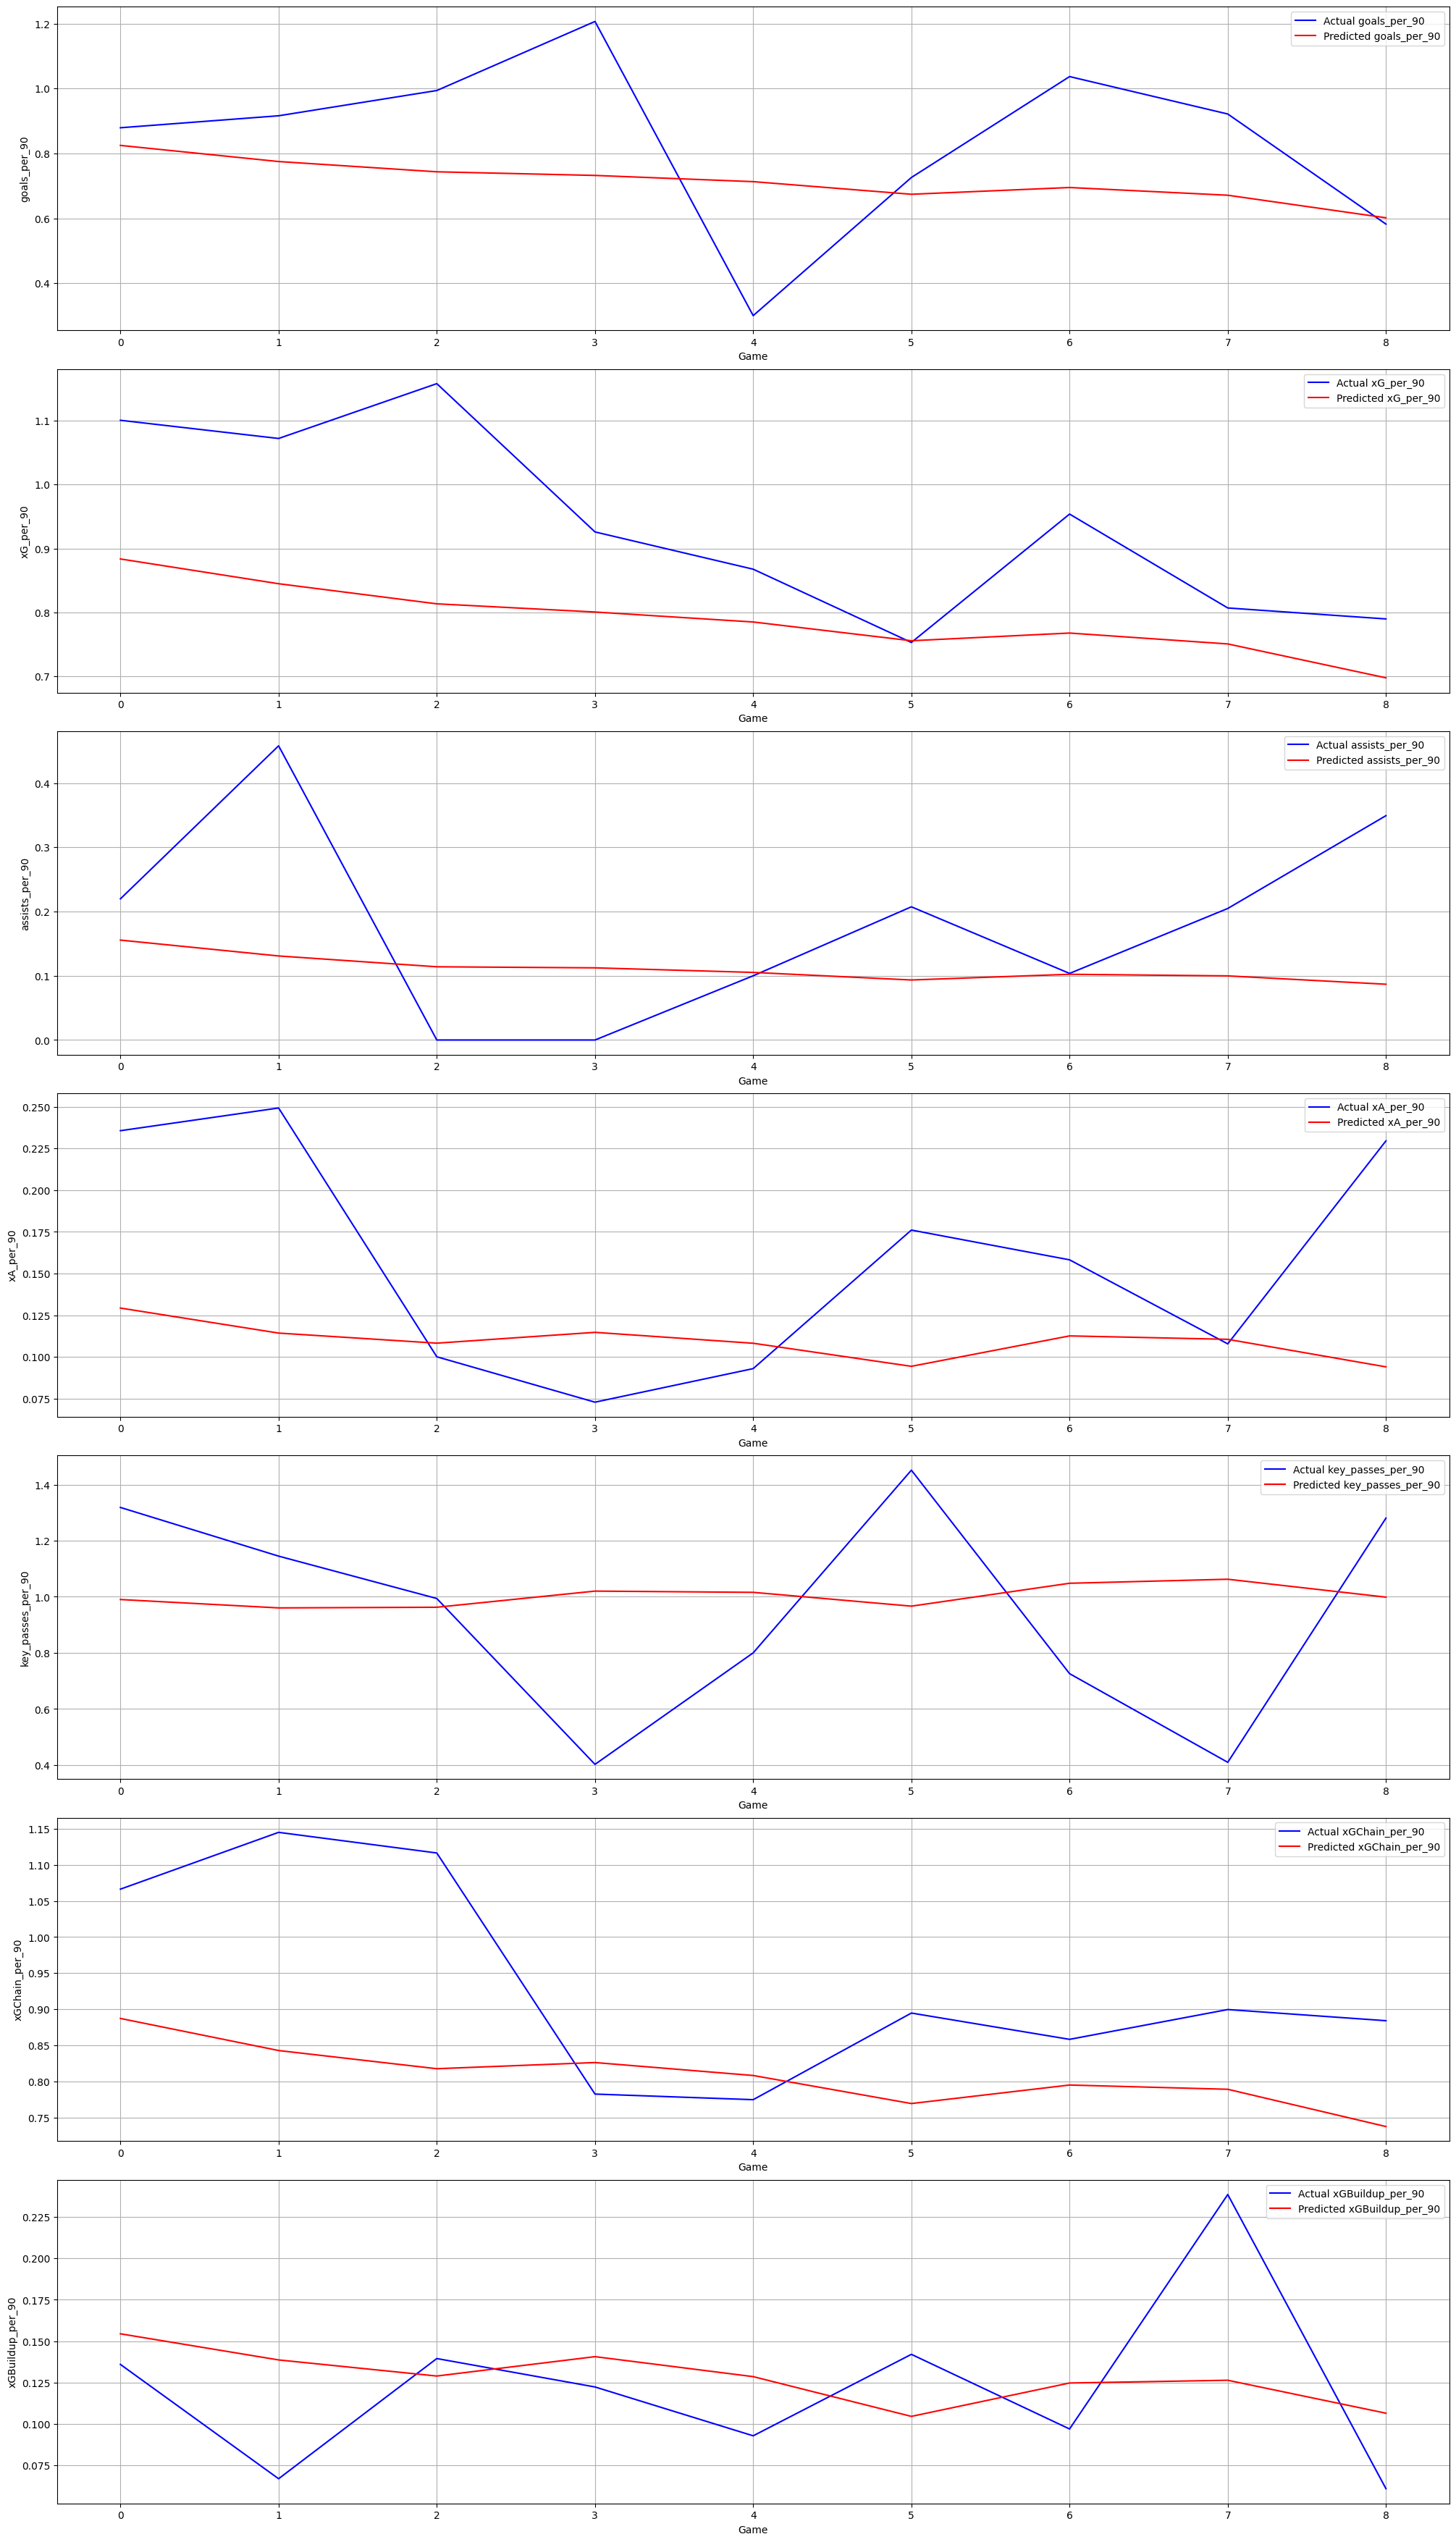

In [12]:
# See how model does on forecasting a specific player--Erling Haaland

haaland_df = f_stats.loc["8260"]

model.eval_model_on_player(haaland_df)